# Task 2 : Credit Risk Prediction 

## Intoduction and Problem Statement 
In this task we have to load a loan prediction dataset using kaggle . In the dataset there might be some missing data we have to handle them . Moreover we need to visuallize the fetures of dataset. Then train a classification model and evaluate the model.

In [33]:
# Import Libraries
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Loading dataset from kaggle of loan prediction 
df = pd.read_csv("loan_data.csv")

## Handling Missing Data

In [51]:
# Finding how many missing values 
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [36]:
# Handling missing values 11 missing valuse filled for Loan amount term 
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

In [37]:
# Handling missing values 30 missing valuse filled for credit history
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())

In [38]:
# Handling missing values 5 missing valuse filled for Gender
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [39]:
# Handling missing Values: 21 values filled for self employed
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

All the missing values in each column were founded by isull().sum().Numerical values filled by using median and others by mode the most frquent value .

## Visualizing Loan amount , Education and Income 

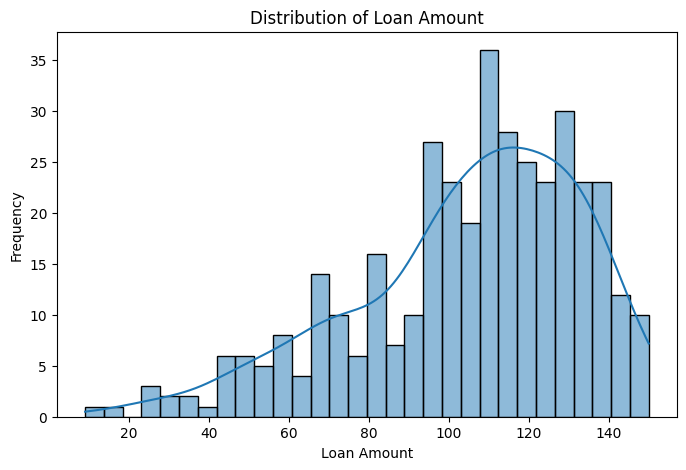

In [40]:
# Aalyzing how the loan amounts are distributed among applicants 
plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], bins=30, kde=True)

plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

plt.show()

The applicants applied in greater number for moderate and larger Loan amount and few apllied for smaller loan amount. 

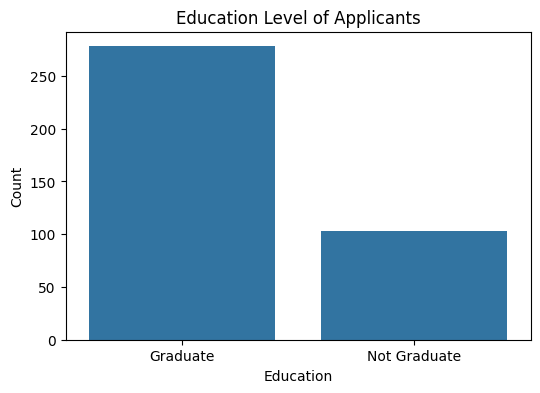

In [41]:
# This shows the number of  graduates 
plt.figure(figsize=(6,4))
sns.countplot(x='Education', data=df)

plt.title('Education Level of Applicants')
plt.xlabel('Education')
plt.ylabel('Count')

plt.show()

More graduates applied for loan compared to non- graduates 

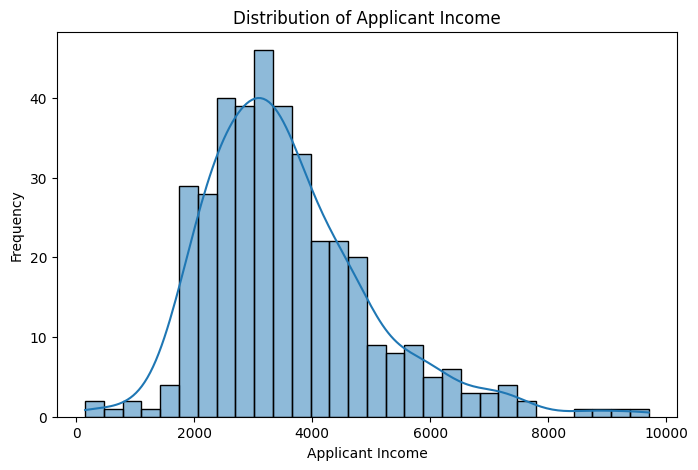

In [42]:
#Income visualiztaion 
plt.figure(figsize=(8,5))
sns.histplot(df['ApplicantIncome'], bins=30, kde=True)

plt.title('Distribution of Applicant Income')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')

plt.show()

The applicants wtih moderate and lower income are greater than applicants with very high incoms.

## Train a Classification model 

In [43]:
# Converting categorical data into numbers 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object','string']).columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
1,1,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
2,2,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
3,3,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
4,4,1,1,0,1,0,2333,1516.0,95.0,360.0,1.0,2,1


In [44]:
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

In [45]:
# Testing 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
# Training Logistic regression 
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=10000)

lr.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [47]:
y_pred_lr = lr.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.8181818181818182


In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[ 7 14]
 [ 0 56]]


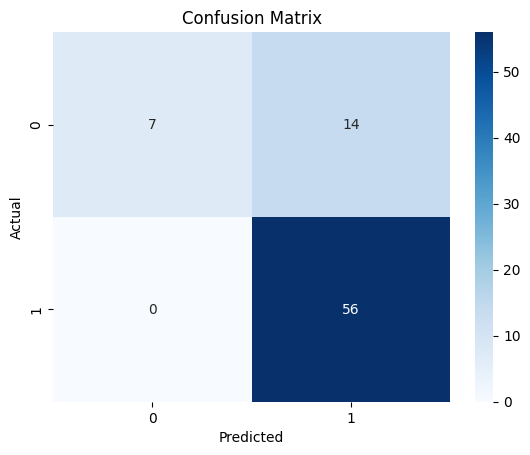

In [50]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Evaluation 
The model was evaluated using accuracy and confusion matrix . Accuracy measuers the overall correct predictions,while confusion matrix provides a detailed breakdown of correct and inccorect classification.

## Conclusion
Logistic regression achieved an accuracy of 0.82 on the test.In this task we had an experience of handling missing data and completing it with the dataset by analysing it using median and mode . Training data and then we evaluaed the accuracy. We also get an estimate of how many predictions were correct and incorrect by comparing the models predicted values with the acutal values using confusion matrix .